In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df = pd.read_json("../data/dataset.json")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           166 non-null    int64 
 1   titulo       166 non-null    object
 2   descripcion  166 non-null    object
 3   tags         166 non-null    object
dtypes: int64(1), object(3)
memory usage: 5.3+ KB


### LISTA DE TODAS LAS ETIQUETAS (TAGS) ÚNICAS

In [7]:
todos_los_tags = [tag for lista in df['tags'] for tag in lista]
conteo_tags = Counter(todos_los_tags)

df_tags = pd.DataFrame(conteo_tags.items(), columns=['Tag', 'Cantidad']).sort_values(by='Cantidad', ascending=False).reset_index(drop=True)

total_apariciones = df_tags['Cantidad'].sum()
df_tags['Porcentaje'] = (df_tags['Cantidad'] / total_apariciones * 100).round(2).astype(str) + '%'

display(df_tags)

,Tag,Cantidad,Porcentaje
0,python,99,31.73%
1,javascript,50,16.03%
2,webdev,31,9.94%
3,r,17,5.45%
4,react,12,3.85%
5,productivity,9,2.88%
6,ai,8,2.56%
7,showdev,7,2.24%
8,beginners,7,2.24%
9,frontend,6,1.92%


## TOP 10 DE TAGS

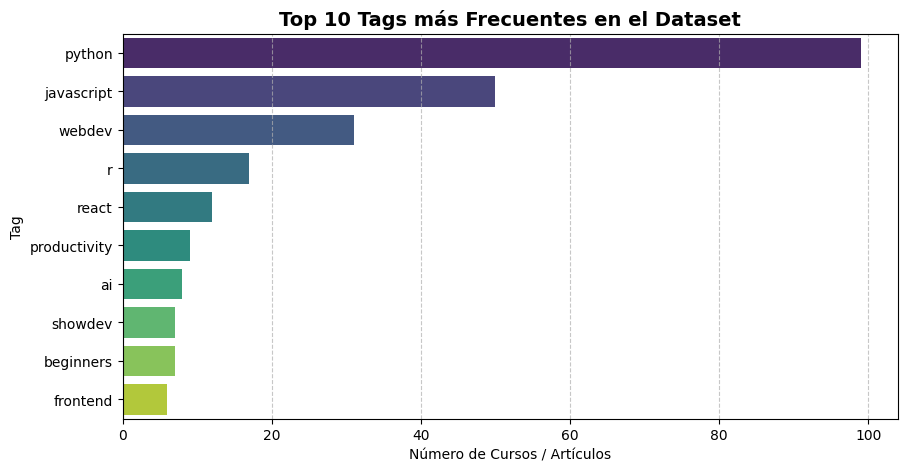

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_tags.head(10),
    x='Cantidad',
    y='Tag',
    hue='Tag',
    palette='viridis',
    legend=False
)
plt.title('Top 10 Tags más Frecuentes en el Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Número de Cursos / Artículos')
plt.ylabel('Tag')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## DISTRIBUCIÓN DE LONGITUD DE DESCRIPCIÓN

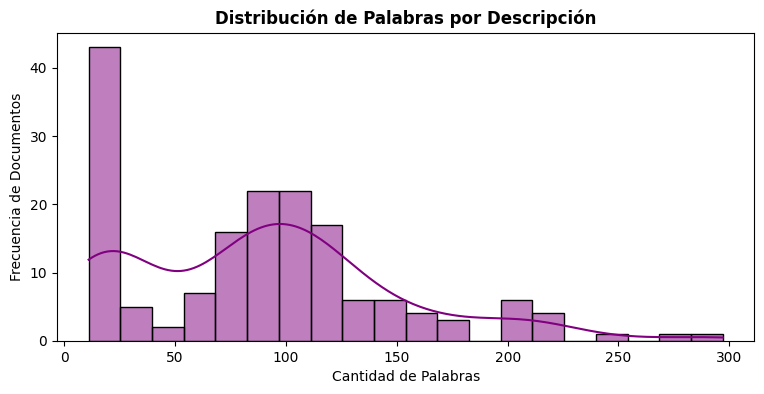


--- Resumen Estadístico de las Descripciones ---
count    166.000000
mean      89.012048
std       59.997676
min       11.000000
25%       22.250000
50%       89.500000
75%      118.750000
max      297.000000
Name: cant_palabras_desc, dtype: float64


In [9]:
df['cant_palabras_desc'] = df['descripcion'].fillna('').apply(lambda x: len(str(x).split()))

plt.figure(figsize=(9, 4))
sns.histplot(df['cant_palabras_desc'], bins=20, kde=True, color='purple')
plt.title('Distribución de Palabras por Descripción', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Palabras')
plt.ylabel('Frecuencia de Documentos')
plt.show()

print("\n--- Resumen Estadístico de las Descripciones ---")
print(df['cant_palabras_desc'].describe())

plt.show()

### Interpretación del gráfico
* **Comportamiento Bimodal Mantendio:** El dataset conserva un total de **166** documentos. La estructura de la distribución sigue siendo bimodal; el pico inicial más alto (a la izquierda) concentra **43** registros correspondientes a descripciones extremadamente cortas (alrededor de 25 palabras o menos). El segundo grupo principal se estabiliza y distribuye alrededor de la mediana, alcanzando su punto máximo cerca de las **100** palabras.
* **Tendencia Central:** Debido a la traducción al español, el volumen de palabras aumentó de forma generalizada. La mediana (percentil 50%) se ubica ahora en **89.5** palabras por descripción, mientras que el promedio general (media) subió a **89.0** palabras.
* **Presencia de Outliers y Asimetría:** Se mantiene una clara asimetría positiva hacia la derecha. El rango de longitud se amplió notablemente, extendiéndose desde un mínimo de **11** palabras hasta un texto atípico máximo (outlier) bastante extenso que alcanza las **297** palabras.